# Extensive BBP Phase Transition (2026)

Author: me

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.stats import ortho_group
import pandas as pd
import os

In [ ]:
# --------------------------------------------
# Plotting Styles
# --------------------------------------------

def load_default_plot_style():
    """
    Sets up the default pyplot style for physical review publication figures.
    """
    import matplotlib.pyplot as plt
    from matplotlib import cycler
    mpl_style = {'axes.formatter.use_mathtext': True,
                 'axes.linewidth': 1.0,
                 'axes.prop_cycle': cycler('color', ['#0C5DA5', '#00B945', '#FF9500', '#FF2C00', '#845B97', '#474747', '#9e9e9e']),
                 'figure.figsize': [3.38582677, 2.5313],
                 'font.family': ['STIXGeneral'],
                 'grid.linewidth': 1.0,
                 'legend.frameon': False,
                 'lines.linewidth': 1.0,
                 'mathtext.fontset': 'stix',
                #  'savefig.bbox': 'tight',
                 'savefig.pad_inches': 0.05,
                 'text.latex.preamble': '\\usepackage{amsmath, amssymb}',
                 'text.usetex': False,
                 'xtick.direction': 'in',
                 'xtick.major.size': 3.0,
                 'xtick.major.width': 0.5,
                 'xtick.minor.size': 1.5,
                 'xtick.minor.visible': True,
                 'xtick.minor.width': 0.5,
                 'xtick.top': True,
                 'ytick.direction': 'in',
                 'ytick.major.size': 3.0,
                 'ytick.major.width': 0.5,
                 'ytick.minor.size': 1.5,
                 'ytick.minor.visible': True,
                 'ytick.minor.width': 0.5,
                 'ytick.right': True}
    plt.style.use(mpl_style)
    
colors = ['#0C5DA5', '#00B945', '#FF9500', '#FF2C00', '#845B97', '#474747', '#9e9e9e']

def nice_points(color):
    return {'color': color, "mfc": get_alpha_hex(color,0.5)}

def hex_to_rgb(value,transmit=None, full=False):
    '''Convert a hex color to rgb tuple.'''
    value = value.lstrip('#')
    lv = len(value)
    step = int(lv/3) 
    scale = 1.0/255.0
    if full:
        scale = 1
    col = tuple(scale*int(value[i:i+step], 16) for i in range(0, lv, step))

    if not transmit:
        return col
    else:
        return col + (transmit,)
    
def rgb_to_hex(value):
    '''Convert a rgb tuple to a hex color string.'''
    if value[0] < 1:
        scale = 255
    else:
        scale = 1
    rgb = [int(scale*k) for k in value]
    return '#%02x%02x%02x' % (rgb[0],rgb[1],rgb[2]) 

def get_alpha_hex(value,alpha):
    '''Convert a hex color to an equivalent non-transparent version.'''

    #first we get the rgb
    rgb = hex_to_rgb(value)

    # apply the transparency
    target = [alpha*k + (0.999-alpha) for k in rgb] 

    return rgb_to_hex(target)



# --------------------------------------------
# Functions
# --------------------------------------------


def MP_law_EV(x_ev, dim_ratio, sigma2 = 1):
    """
    x_ev: array (eigenvalue variable)
    dim_ratio: scalar (dimension ratio)
    sigma2: scalar (variance, squared value already)
    
    output: array (MP law for eigenvalues)
    """
    # Bulk boundaries and step function (zero outside boundaries).
    boundary_left = sigma2 * (1 - 1/np.sqrt(dim_ratio))**2
    boundary_right = sigma2 * (1 + 1/np.sqrt(dim_ratio))**2
    cases = np.heaviside(x_ev - boundary_left, 0) * np.heaviside(boundary_right - x_ev, 0)
    
    return np.sqrt(np.abs((boundary_right - x_ev) * (x_ev - boundary_left))) / (2 * np.pi * x_ev * sigma2) * dim_ratio * cases


# Create a random matrix of given dimensions with a set of variances.
def get_matrix(q, A, variances, seed):
    """
    Creates a rectangular matrix with random entries, drawn according to variances.
    
    q: scalar (column dimension)
    A: scalar (dimension ratio)
    variances: either 1D array with q entries or 2D array in the form of a histogram (variance values and multiplicities)
    
    output: 2D array (random matrix where each row is independent and each j-th column is drawn according to the j-th variance)
    """
    # Create array of q variances from a histogram if not already in that form.
    length = len(np.shape(variances))      
    if length == 2: 
        mults = np.trim_zeros(variances[1]) # multiplicities in second array
        variances = np.repeat(variances[0][0:len(mults)], mults) # actual variance values in first array
    
    elif length != 1:
        print("Please insert a 1D or 2D array for the variances.")
        
    p = int(q*A) 
    
    # Create columns of matrix by drawing elements from normal distributions with given variances.
    my_scale = np.vstack([np.sqrt(variances/p)]*p) # p rows of q deviations (= variance square-root)
    my_size = [p, q] # draw p vectors of size q
        
    return np.random.default_rng(seed=seed).normal(loc=0, scale=my_scale, size=my_size) # matrix of dim. p x q (rows are drawn vectors)


def signal_matrix(q, A, signal_SVs):
    """
    Creates a rectangular matrix with the signal singular values on the diagonal.
    """
    p = int(q*A)
    mat = np.zeros((p, q))
    for i in range(len(signal_SVs)):
        mat[i, i] = signal_SVs[i]
    return mat


# Spectrum from Green function
def PDF_from_Green(G_vals, make_positive = False):
    """
    Turns Green function values into probability density values.
    
    G_vals: array (Green function values)
    
    output: array (spectral density P(x))
    """
    if make_positive:
        return np.abs(np.imag(G_vals)) / np.pi
    else:
        return - np.imag(G_vals) / np.pi
    

# Exact Green function
def poly_solutions(z, sigma, A, rank_ratio, theta):
    """
    Calculates the four solutions of the quartic polynomial.
    """
    poly_A = z**2 * sigma**6 / A**3
    poly_B = sigma**4 / A**2 * (2 * z * sigma**2 * (1 - 1/A) - 3 * z**2)
    poly_C = sigma**2 / A * (3 * z**2 - z * theta**2 + sigma**4 * (1 - 1/A)**2 - 4 * z * sigma**2 * (1 - 1/A) + z * sigma**2 / A)
    poly_D = - theta**2 * (sigma**2 * (1 - 1/A) - z) + 2 * z *sigma**2 * (1 - 1/A) - sigma**4 * (1 - 1/A)**2 - z**2 + sigma**4 / A * (1 - 1/A) - 2 * z * sigma**2 / A 
    poly_E = z - sigma**2 * (1 - 1/A) - (1 - rank_ratio) * theta**2

    a = - 3 * poly_B**2 / (8 * poly_A**2) + poly_C / poly_A
    b = poly_B**3 / (8 * poly_A**3) - poly_B * poly_C / (2 * poly_A**2) + poly_D / poly_A
    c = - 3 * poly_B**4 / (256 * poly_A**4) + poly_C * poly_B**2 / (16 * poly_A**3) - poly_B * poly_D / (4 * poly_A**2) + poly_E / poly_A
    
    m = - a**2 / 12 - c
    n = - a**3 / 108 + a * c / 3 - b**2 / 8
    
    unit_root = -1/2 + np.sqrt(3)/2 *1j
    
    y = a / 6 + np.power(- n / 2 + np.sqrt(n**2 / 4 + m**3 / 27), (1/3)) - m / 3 / np.power(- n / 2 + np.sqrt(n**2 / 4 + m**3 / 27), (1/3))
#     y = a / 6 + unit_root * np.power(- n / 2 + np.sqrt(n**2 / 4 + m**3 / 27), (1/3)) - unit_root * m / 3 / np.power(- n / 2 + np.sqrt(n**2 / 4 + m**3 / 27), (1/3))
#     y = a / 6 + unit_root**2 * np.power(- n / 2 + np.sqrt(n**2 / 4 + m**3 / 27), (1/3)) - unit_root**2 * m / 3 / np.power(- n / 2 + np.sqrt(n**2 / 4 + m**3 / 27), (1/3))

    G_1 = ( - np.sqrt(2 * y - a) + np.sqrt(- 2 * y - a + 2 * b / np.sqrt(2 * y - a)) ) / 2 - poly_B / (4 * poly_A)
    G_2 = ( - np.sqrt(2 * y - a) - np.sqrt(- 2 * y - a + 2 * b / np.sqrt(2 * y - a)) ) / 2 - poly_B / (4 * poly_A)
    G_3 = ( + np.sqrt(2 * y - a) + np.sqrt(- 2 * y - a - 2 * b / np.sqrt(2 * y - a)) ) / 2 - poly_B / (4 * poly_A)
    G_4 = ( + np.sqrt(2 * y - a) - np.sqrt(- 2 * y - a - 2 * b / np.sqrt(2 * y - a)) ) / 2 - poly_B / (4 * poly_A)
    
    return np.array([G_1, G_2, G_3, G_4])



# Discriminant and Spectrum Roots
def discriminant_fast(z, sigma, A, rank_ratio, theta):
    """
    Calculates the discriminant of the quartic polynomial.
    """
    poly_A = z**2 * sigma**6 / A**3
    poly_B = sigma**4 / A**2 * (2 * z * sigma**2 * (1 - 1/A) - 3 * z**2)
    poly_C = sigma**2 / A * (3 * z**2 - z * theta**2 + sigma**4 * (1 - 1/A)**2 - 4 * z * sigma**2 * (1 - 1/A) + z * sigma**2 / A)
    poly_D = - theta**2 * (sigma**2 * (1 - 1/A) - z) + 2 * z *sigma**2 * (1 - 1/A) - sigma**4 * (1 - 1/A)**2 - z**2 + sigma**4 / A * (1 - 1/A) - 2 * z * sigma**2 / A 
    poly_E = z - sigma**2 * (1 - 1/A) - (1 - rank_ratio) * theta**2
    
    term_1 = 256 * poly_A**3 * poly_E**3 - 192 * poly_A**2 * poly_B * poly_D * poly_E**2 - 128 * poly_A**2 * poly_C**2 * poly_E**2 + 144 * poly_A**2 * poly_C * poly_D**2 * poly_E
    term_2 = - 27 * poly_A**2 * poly_D**4 + 144 * poly_A * poly_B**2 * poly_C * poly_E**2 - 6 * poly_A * poly_B**2 * poly_D**2 * poly_E - 80 * poly_A * poly_B * poly_C**2 * poly_D * poly_E
    term_3 = 18 * poly_A * poly_B * poly_C * poly_D**3 + 16 * poly_A * poly_C**4 * poly_E - 4 * poly_A * poly_C**3 * poly_D**2 - 27 * poly_B**4 * poly_E**2 + 18 * poly_B**3 * poly_C * poly_D * poly_E
    term_4 = - 4 * poly_B**3 * poly_D**3 - 4 * poly_B**2 * poly_C**3 * poly_E + poly_B**2 * poly_C**2 * poly_D**2
    
    return term_1 + term_2 + term_3 + term_4


def roots_from_data_fast(x, y):
    """
    Determines the roots from a discrete array (either when y = 0 exactly or when y changes its sign).
    """
    x_array = np.array(x)
    y_array = np.array(y)
    
    actual_zeros = x_array[y_array == 0]
    
    signs = np.sign(y_array)
    flips = (signs[0:-1:] * signs[1::] < 0)
    proximity_zeros = x_array[0:-1:][flips] + np.diff(x_array)[flips] / 2
    
    return np.sort(np.unique(np.concatenate((actual_zeros, proximity_zeros))))


def upper_MP_bound_EV(sigma, A):
    """
    Calculates the upper boundary of the Marchenko-Pastur law (location of the phase transition in low-rank limit).
    """
    return sigma**2 * (1 + 1/np.sqrt(A))**2


def fullrank_endpoint(sigma, A):
    """
    Calculates the endpoint (full-rank limit) of the phase transition line for the phase diagram.
    """
    return sigma**2 / A * (1 + np.sqrt(A - 1))


def sqrt_0_radicand(z, sigma, A, rank_ratio, theta):
    """
    Calculates the radicand of the relevant square-root in the quartic polynomial's solution G (just the inside of the square-root)
    """
    poly_A = z**2 * sigma**6 / A**3
    poly_B = sigma**4 / A**2 * (2 * z * sigma**2 * (1 - 1/A) - 3 * z**2)
    poly_C = sigma**2 / A * (3 * z**2 - z * theta**2 + sigma**4 * (1 - 1/A)**2 - 4 * z * sigma**2 * (1 - 1/A) + z * sigma**2 / A)
    poly_D = - theta**2 * (sigma**2 * (1 - 1/A) - z) + 2 * z *sigma**2 * (1 - 1/A) - sigma**4 * (1 - 1/A)**2 - z**2 + sigma**4 / A * (1 - 1/A) - 2 * z * sigma**2 / A 
    poly_E = z - sigma**2 * (1 - 1/A) - (1 - rank_ratio) * theta**2
    
    a = - 3 * poly_B**2 / (8 * poly_A**2) + poly_C / poly_A
    b = poly_B**3 / (8 * poly_A**3) - poly_B * poly_C / (2 * poly_A**2) + poly_D / poly_A
    c = - 3 * poly_B**4 / (256 * poly_A**4) + poly_C * poly_B**2 / (16 * poly_A**3) - poly_B * poly_D / (4 * poly_A**2) + poly_E / poly_A
    
    m = - a**2 / 12 - c
    n = - a**3 / 108 + a * c / 3 - b**2 / 8
    
    return n**2 / 4 + m**3 / 27


def signal_for_first_inner_boundary_rad(theta_axis, EV_axis, sigma, A, rank_ratio):
    """
    Computes the spectral boundaries using the relevant radicand of the G solution 
    and returns the first theta value (smallest signal) for which there is an inner boundary.
    """
    previous_theta = 0
    
    for theta_single in theta_axis:
        rad = sqrt_0_radicand(EV_axis, sigma, A, rank_ratio, theta_single)
        root_set = roots_from_data_fast(EV_axis, rad)
        root_set = root_set[root_set < theta_single**2 + 4.2 * sigma**2 * (1 + 1/np.sqrt(A))**2] # no coincidental high values
                
        if A == 1:
            root_set = np.concatenate((np.zeros(1), root_set)) # put 0 as the lower boundary for A = 1
        
        root_set = np.unique(root_set)
                    
        # if len(root_set) == 4: 
        if len(root_set) >= 4:
            return (theta_single**2, theta_single**2 - previous_theta**2, root_set)
        
        previous_theta = theta_single
        
    return (np.nan, np.nan, np.nan)


def signal_for_first_inner_boundary_algorithm(theta_bounds, EV_axis, sigma, A, rank_ratio, tol = 1e-3, max_iter = 20):

    a = theta_bounds[0]
    b = theta_bounds[1]

    for _ in range(max_iter):
        if b - a <= tol:
            break
        c = (a + b) / 2
        rad = sqrt_0_radicand(EV_axis, sigma, A, rank_ratio, theta=c)
        root_set = roots_from_data_fast(EV_axis, rad)
        root_set = root_set[root_set < c**2 + 4 * upper_MP_bound_EV(sigma, A)] # no coincidental high values
                
        if A == 1:
            root_set = np.concatenate((np.zeros(1), root_set)) # put 0 as the lower boundary for A = 1
        
        root_set = np.unique(root_set)
                    
        if len(root_set) >= 4:
            b = c
        else:
            a = c
    
    return (c**2, b**2 - a**2, root_set)


# Pre-defined Colors
my_colors_exp = ["#1f77b4", "#ff7f0e", "#2ca02c"]
my_colors_theo = ["cyan", "maroon", "lightgreen"]

# Load plot style
load_default_plot_style()

# Create Folders for Data and Plots
os.makedirs("./output", exist_ok=True)
os.makedirs("./plots", exist_ok=True)

## Splitting of the Spectrum

In [25]:
# Splitting Signal for Figure 1b

A = 2
sigma = 1
rank_ratio = 0.2

max_theta = np.sqrt(9)
EV_axis = np.linspace(0, max_theta**2 * sigma**2 + 1 * sigma**2, 10**4 + 1)[1::]

crit_signal, error, roots = signal_for_first_inner_boundary_algorithm(
    theta_bounds = [0.9 * sigma**2 / np.sqrt(A), 4 * sigma**2 / np.sqrt(A)], 
    EV_axis = EV_axis, 
    sigma = sigma, 
    A = A, 
    rank_ratio = rank_ratio, 
    tol = 1e-5, 
    max_iter = 20
)

print(f"Critical signal for A = {A} and rank ratio = {rank_ratio}:", crit_signal, "(approx.)")
print(f"Roots at critical signal:", roots)


Critical signal for A = 2 and rank ratio = 0.2: 1.8205911942933015 (approx.)
Roots at critical signal: [0.0955 2.2735 2.2745 4.9145]


In [22]:
def compute_theoretical_spectra(theta_cases, EV_axis, sigma, A, rank_ratio):
        
    Green_theo = [poly_solutions(EV_axis + 1e-10 * 1j, sigma, A, rank_ratio, theta) for theta in theta_cases]
    PDF_theo = [PDF_from_Green(Green_theo[i]) for i in range(len(theta_cases))]
    PDF_theo = [np.sum(np.maximum(0, PDF_theo[i]), axis=0) for i in range(len(theta_cases))]

    return PDF_theo


def simulate_empirical_spectra(theta_cases, sigma, A, rank_ratio, dim_q, num_of_runs, bin_interval=None, seed=0):
    histo_q_collection = [0]*len(theta_cases)

    for i in range(len(theta_cases)):
        signal_SVs = np.ones(int(rank_ratio * dim_q)) * theta_cases[i] 
        
        start = time.time()
        exp_SV_q_collection = np.empty((num_of_runs, dim_q)) 
        var_samples_q = np.ones(dim_q) * sigma**2
        for j in range(num_of_runs):
            exp_SV_q_collection[j] = np.linalg.svd(get_matrix(dim_q, A, var_samples_q, seed=seed+j) + signal_matrix(dim_q, A, signal_SVs), compute_uv=False)
        end = time.time()
        print(f"Time for SV calculation (A = {A}, q = {dim_q}) =", end - start, "s")
        
        exp_EV_q_collection = exp_SV_q_collection.flatten()**2 # squaring gives eigenvalues of sample covariance matrix

        if bin_interval is None:
            low = np.min(exp_EV_q_collection)
            high = np.max(exp_EV_q_collection)
        else:
            low = bin_interval[0]
            high = bin_interval[1]
        histo_q_collection[i] = np.histogram(exp_EV_q_collection, bins = np.linspace(low, high, 151), density=True) # bins = np.linspace(np.min(exp_EV_q_collection), np.max(exp_EV_q_collection), 10**2)

    return histo_q_collection
    


def plot_three_spectra(theta_cases, EV_axis, MP_law_EV, histo_q_collection, PDF_theo, sigma, A, rank_ratio, xlim=None, ylim=None):
    """
    Plots the spectra for the different theta cases, including the MP law, the histogram from the experiment and the exact solution.
    """
    figs = [0]*len(theta_cases)

    for i in range(len(theta_cases)): 

        fig, ax = plt.subplots(figsize=(3.38582677, 2.093), constrained_layout=True)

        ax.plot(EV_axis, MP_law_EV(EV_axis, A, sigma2 = sigma**2), "--", color = "black", label = r"MP law")   
        ax.bar(histo_q_collection[i][1][:-1:], histo_q_collection[i][0], color = my_colors_exp[0], align = "edge", width = np.diff(histo_q_collection[i][1]), label = r"simulation") # "center"
        ax.plot(EV_axis, PDF_theo[i], "-", color = my_colors_exp[1], label = f"exact")   
        ax.set_xlim(xlim or [0, 8])
        ax.set_ylim(ylim or [0, 1])
        ax.set_xlabel(r"eigenvalue $x$", fontsize=13)
        ax.set_ylabel(r"density $P(x)$", fontsize=13)
        ax.tick_params(axis='both', labelsize=12)
        ax.set_xscale("linear")
        ax.set_yscale("linear")
        ax.legend(loc = "upper right", fontsize=12, handlelength=1.5, handleheight=0.5)

        figs[i] = fig

    plt.show()

    return figs



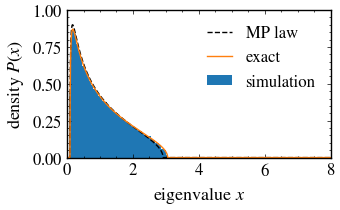

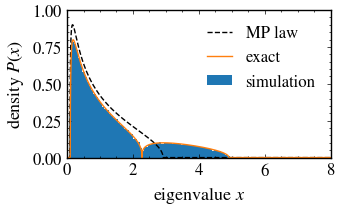

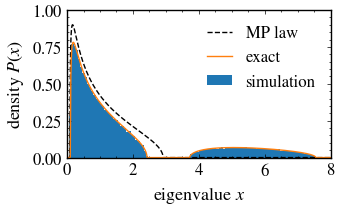

In [ ]:
# Parameters
sigma = 1
A = 2
rank_ratio = 0.2
theta_cases = np.sqrt(np.array([0.2, 1.82, 4])) 
EV_axis = np.linspace(0, 11, 10**4 + 1)[1::]

# Exact
PDF_theo = compute_theoretical_spectra(
    theta_cases, 
    EV_axis, 
    sigma, 
    A, 
    rank_ratio
)

# Experiment
histo_q_collection = simulate_empirical_spectra(
    theta_cases, 
    sigma,
    A, 
    rank_ratio, 
    dim_q = 1000, 
    num_of_runs = 10,
    bin_interval = (0, 10),
    seed = 0
)

# Plot
figs = plot_three_spectra(
    theta_cases, 
    EV_axis, 
    MP_law_EV, 
    histo_q_collection, 
    PDF_theo, 
    sigma, 
    A, 
    rank_ratio
)

panel_labels = ["a", "b", "c"] # one panel for each theta case
for i, fig in enumerate(figs):
    fig.savefig(f"./plots/Spectrum-Splitting_A{A}_r{round(rank_ratio*100)}-{panel_labels[i]}.pdf")

### Boundaries Depending on the Signal

In [5]:
def compute_boundaries(theta_axis, EV_axis, sigma, A, rank_ratio):
    """
    Computes the boundaries of the spectrum for a range of theta values.
    """
    
    my_discriminant_vals = [sqrt_0_radicand(EV_axis, sigma, A, rank_ratio, theta_single) for theta_single in theta_axis] # rescaled discriminant values
    my_roots = [roots_from_data_fast(EV_axis, _) for _ in my_discriminant_vals]

    if A == 1:
        for i in range(len(my_roots)):
            my_roots[i] = np.concatenate((np.zeros(1), np.array([np.nan]*(3-len(my_roots[i]))), my_roots[i]))
    else:
        for i in range(len(my_roots)):
            my_roots[i] = np.concatenate((np.array([np.nan]*(4-len(my_roots[i]))), my_roots[i]))
        
    crit_signal, error_, roots_ = signal_for_first_inner_boundary_rad(theta_axis, EV_axis, sigma, A, rank_ratio)
        
    my_roots = np.array(my_roots)
    my_theta2_plot_axis = theta_axis**2

    return my_theta2_plot_axis, my_roots, crit_signal


def plot_boundaries_of_theta(theta_axis, roots, crit_signal):

    fig, ax = plt.subplots(figsize=(3.38582677, 2.093), constrained_layout=True)

    ax.axvline(crit_signal, ls = ":", color = "grey", label = r"$\vartheta^2_{\mathrm{crit}}$")
    ax.plot(theta_axis, roots[:, 0], "-", color = my_colors_exp[0], label = f"$x_{1}, x_{4}$")
    ax.plot(theta_axis, roots[:, 1], "-", color = my_colors_exp[1], label = f"$x_{2}, x_{3}$")
    ax.plot(theta_axis, roots[:, 2], "-", color = my_colors_exp[1])
    ax.plot(theta_axis, roots[:, 3], "-", color = my_colors_exp[0])
    ax.set_ylim([-0.5, 13.5])
    ax.set_xlabel(r"signal $\vartheta^2$")
    ax.set_ylabel(r"boundary points")
    ax.set_xscale("linear")
    ax.set_yscale("linear")
    ax.legend()
    plt.show()

    return fig

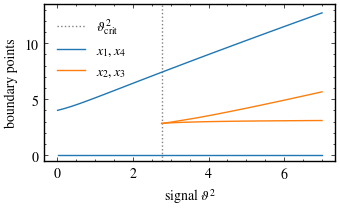

In [6]:
A = 1
sigma = 1
rank_ratio = 0.2
max_theta = np.sqrt(9)
my_theta_axis = np.sqrt(np.linspace(0, max_theta**2 -2, 10**3 +1))[1::]
my_EV_axis = np.linspace(0, max_theta**2 + 10, 10**4 + 1)[1::]

theta_axis, roots, crit_signal = compute_boundaries(my_theta_axis, my_EV_axis, sigma, A, rank_ratio)
fig = plot_boundaries_of_theta(theta_axis, roots, crit_signal)

## Phase Transition

In [ ]:
def define_rank_ratios_for_phase_diagram():
    rank_ratios= np.logspace(-6, np.log10(0.04), 10 + 1)
    rank_ratios = np.concatenate((rank_ratios, np.linspace(rank_ratios[-1], 1 - rank_ratios[-1], 25 + 1)[1:-1]))
    rank_ratios = np.concatenate((rank_ratios, 1 - np.logspace(-6, np.log10(0.04), 10 + 1)[::-1]))
    
    return rank_ratios


def compute_critical_signal_for_phase_diagram(rank_ratios, sigma, A, max_theta = np.sqrt(9), save_csv = False, load_csv = False):

    if load_csv:
        df = pd.read_csv(f"./output/phase_diagram_data_A{A}.csv")
        rank_ratios = df["rank ratio"].values
        all_intersections_r = df["values"].values 
        errors_r = df["errors"].values 
        
        return {"rank ratio": rank_ratios, "values": all_intersections_r, "errors": errors_r}
    
    # Otherwise, compute the data and save it.

    data = {"rank ratio": rank_ratios}

    theta_axis = np.sqrt(np.linspace(0.9 * sigma**2 / np.sqrt(A), 4 * sigma**2 / np.sqrt(A), 10**3 +1))[1::] 
    
    if A == 1:
        EV_axis = np.logspace(-14, -3, 10**4 + 1)
        EV_axis = np.concatenate((EV_axis, np.linspace(EV_axis[-1], max_theta**2 * sigma**2 + 10 * sigma**2, 10**5 + 1)[1::])) # make sure outer boundaries are included
    else:
        EV_axis = np.linspace(0, max_theta**2 * sigma**2 + 1 * sigma**2, 1 * 10**5 + 1)[1::]

    roots_r = [0]*len(rank_ratios)
    errors_r = np.empty(len(rank_ratios))
    all_intersections_r = np.empty(len(rank_ratios))

    for ind, rank_ratio in enumerate(rank_ratios):
        all_intersections_r[ind], errors_r[ind], roots_r[ind] = signal_for_first_inner_boundary_algorithm([theta_axis[0], theta_axis[-1]], EV_axis, sigma, A, rank_ratio, tol = 1e-3, max_iter = 20)
        print(np.round(100 * (ind + 1) / len(rank_ratios), 0), "% done.")

    data[f"values"] = (all_intersections_r) / sigma**2
    data[f"errors"] = (errors_r) / sigma**2

    if save_csv:
        df = pd.DataFrame(data)
        df.to_csv(f"./output/phase_diagram_data_A{A}.csv", index=False)

        print(f"Data saved to ./output/phase_diagram_data_A{A}.csv")

    return data


def plot_phase_diagram(all_data, sigma, xlim=None, ylim=None):

    my_A = sorted(list(all_data.keys()))

    fig, ax = plt.subplots(figsize=(3.38582677, 2.093), constrained_layout=True)

    for i, A in enumerate(my_A):
        ax.plot([0], [1/np.sqrt(A)], "o", color = "grey") # , label = "BBP point"
        ax.plot([1], [fullrank_endpoint(sigma, A) / sigma**2], "o", color = "black") # , label = "BBP analog"
        ax.plot(all_data[A][f"rank ratio"], all_data[A][f"values"], "-", color = my_colors_exp[i], label = f"$\\mathcal{{A}} = {A}$")
    #     ax.errorbar(all_data[A][f"rank ratio"], all_data[A][f"values"], yerr = all_data[A][f"errors"], ls = "-", marker = ".", label = f"$\\mathcal{{A}} = {A}$")

    ax.text(0.3, 0.8, "signal phase", horizontalalignment = "center", verticalalignment = "center", transform = ax.transAxes, fontsize=10)
    ax.text(0.3, 0.08, "MP phase", horizontalalignment = "center", verticalalignment = "center", transform = ax.transAxes, fontsize=10)

    ax.set_xlabel(r"rank ratio $\tilde{r}$", fontsize=10)
    ax.set_ylabel(r"critical signal $\vartheta^2_{\mathrm{crit}} / \sigma^2$", fontsize=10)
    ax.tick_params(axis='both', labelsize=10)
    ax.set_xscale("linear")
    ax.set_yscale("linear")
    ax.legend(loc = "upper right", fontsize=9, handlelength=1.5, handleheight=0)

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.show()

    return fig

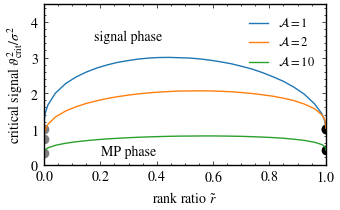

In [ ]:
# ETA = 1 h

# Parameters
my_A = [1, 2, 10]
sigma = 1
max_theta = np.sqrt(9)

# Compute data for phase diagram
all_data = {}
rank_ratios = define_rank_ratios_for_phase_diagram()
for A in my_A:
    all_data[A] = compute_critical_signal_for_phase_diagram(rank_ratios, sigma, A, max_theta = max_theta, save_csv = False, load_csv = True)

# Plot
fig = plot_phase_diagram(all_data, sigma, xlim = [0 - 0.001, 1 + 0.001], ylim = [0, 4.5 - 0.001])

fig.savefig(f"./plots/Phase-Diagram-Signal-over-Rank-Ratio-All-A.pdf")


## Low-Rank Scaling

In [11]:
def define_EV_axis_for_low_rank_behavior(sigma, A, max_theta, Delta):
    EV_axis = np.concatenate(
        (np.linspace(0, upper_MP_bound_EV(sigma, A) - Delta, 10**4 + 1)[1::], 
         np.linspace(upper_MP_bound_EV(sigma, A) - Delta, upper_MP_bound_EV(sigma, A) + Delta, 10*10**5 + 1)[1::], # 5*10**5 
         np.linspace(upper_MP_bound_EV(sigma, A) + Delta, max_theta**2 + 1, 10**4 + 1)[1::])
    )

    return EV_axis


def compute_low_rank_behavior(rank_ratios, sigma, A, max_theta = np.sqrt(9), save_csv = False, load_csv = False):
    
    if load_csv:
        df = pd.read_csv(f"./output/low_rank_behavior_A{A}.csv")
        rank_ratios = df["rank ratio"].values
        all_intersections_r = df["values"].values 
        errors_r = df["errors"].values 
        
        return {"rank ratio": rank_ratios, "values": all_intersections_r, "errors": errors_r}
    
    
    # Otherwise, compute the data and save it.
    theta_axis = np.sqrt(np.linspace(0.9 * sigma**2 / np.sqrt(A), 3 * sigma**2 / np.sqrt(A), 10**3 +1))[1::] 
    
    data = {"rank ratio": rank_ratios}
    print(f"Aspect ratio A = {A}: computing critical signal...")
     
    roots_r = [0]*len(rank_ratios)
    errors_r = np.empty(len(rank_ratios))
    all_intersections_r = np.empty(len(rank_ratios))

    for ind, rank_ratio in enumerate(rank_ratios):
        Delta = min(rank_ratio**(1/4), 0.5)
        EV_axis = define_EV_axis_for_low_rank_behavior(sigma, A, max_theta, Delta)

        all_intersections_r[ind], errors_r[ind], roots_r[ind] = signal_for_first_inner_boundary_algorithm([theta_axis[0], theta_axis[-1]], EV_axis, sigma, A, rank_ratio, tol = 1e-5, max_iter = 20)
        print(np.round(100 * (ind + 1) / len(rank_ratios), 0), "% done.")
        
    data[f"values"] = (all_intersections_r) / sigma**2
    data[f"errors"] = (errors_r) / sigma**2
    
    if save_csv:
        df = pd.DataFrame(data)
        df.to_csv(f"./output/low_rank_behavior_A{A}.csv", index=False)

        print(f"Data saved to ./output/low_rank_behavior_A{A}.csv")

    return data


def plot_low_rank_behavior(all_data, rank_ratios_theo, theo_crit_signal_scaling_A1=None, xlim=None, ylim=None):

    my_A = sorted(list(all_data.keys()))

    fig, ax = plt.subplots(figsize=(3.38582677, 2.093), constrained_layout=True)

    for i, A in enumerate(my_A):
        rank_ratios = all_data[A]["rank ratio"]
        # ax.plot(rank_ratios, fitted_lines[A], "--", color = "grey")

        ax.plot(rank_ratios_theo, 3 / 2 * (1 + A**(1/2))**(2/3) / A**(5/6) * rank_ratios_theo**(1/3), ls="--", color=my_colors_theo[i])


        yerr = np.array(all_data[A]["errors"]) 
        ax.errorbar(rank_ratios, np.array(all_data[A]["values"]) - 1/np.sqrt(A), yerr = yerr, ls = "", marker = ".", color = my_colors_exp[i], label = f"$\\mathcal{{A}} = {A}$")

        if A == 1 and theo_crit_signal_scaling_A1 is not None:
            ax.plot(rank_ratios_theo, theo_crit_signal_scaling_A1 - 1/np.sqrt(A), "--", color = my_colors_exp[i], label = f"$\\mathcal{{A}} = {A}$ (theo.)")
        
    ax.set_xlabel(r"rank ratio $\tilde{r}$", fontsize=10)
    ax.set_ylabel(r"critical signal $\vartheta^2_{\mathrm{crit}} / \sigma^2 - \mathcal{A}^{-1/2}$", fontsize=10)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(loc = "upper left", fontsize=9, handlelength=1.5, handleheight=0)

    ax.tick_params(axis='both', labelsize=10)
    
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.show()

    return fig

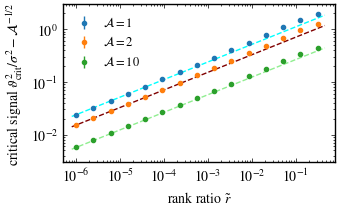

In [ ]:
# ETA = 10 min

# Parameters
my_A = [1, 2, 10]
sigma = 1
rank_ratios = np.logspace(-6, -1/2, 14 + 1)
max_theta = np.sqrt(9)

all_data = {}
for A in my_A:
    all_data[A] = compute_low_rank_behavior(rank_ratios, sigma, A, max_theta = max_theta, save_csv = False, load_csv = True)

rank_ratios_theo = np.logspace(-6.1, -1/3, 30 + 1)
# theo_crit_signal_scaling_A1 = compute_A1_critical_signal_theta(rank_ratios_theo, sigma)**2

fig = plot_low_rank_behavior(all_data, rank_ratios_theo, theo_crit_signal_scaling_A1=None, xlim = [5e-7, 8e-1], ylim = [3e-3, 3e-0]) # xlim = [5e-7, 2e-1], ylim = [3e-3, 3e-0] # xlim = [5e-10, 2e-1], ylim = [3e-4, 3e-0]

fig.savefig(f"./plots/Rank-Ratio-Scaling-Theo-Exp.pdf")

## Large Signal Approximation

In [ ]:
def large_signal_Green(z, sigma, A, rank_ratio, theta):
    """
    Computes the approximation of the Green function in the large-signal regime.
    """
    pref = z - theta**2 - sigma**2 * (1 - 3/A)
    sqrt = np.sqrt(pref**2 - 8 * sigma**2 / A * (z - theta**2 - sigma**2 * (1 - 1/A) + rank_ratio * theta**2))
    G_plus = A/(4*z*sigma**2) * (pref + sqrt)
    G_minus = A/(4*z*sigma**2) * (pref - sqrt)
    
    return np.array([G_plus, G_minus])


def large_signal_PDF(x, sigma, A, rank_ratio, theta):   
    """
    Computes the approximation of the spectral probability density in the large-signal regime.
    """
    lim_up = theta**2 + sigma**2 * (1 + 1/A) + np.sqrt(8 * sigma**2 / A * rank_ratio * theta**2)
    lim_low = theta**2 + sigma**2 * (1 + 1/A) - np.sqrt(8 * sigma**2 / A * rank_ratio * theta**2)
    
    cases = np.where((x - lim_low) * (lim_up - x) > 0, 1, 0)

    return A/(4*x*np.pi*sigma**2) * np.sqrt((x - lim_low) * (lim_up - x) * cases)



def compute_theoretical_spectrum(EV_axis, sigma, A, rank_ratio, theta):
    """
    Computes the theoretical spectrum for given parameters.
    """
    Green_theo = poly_solutions(EV_axis + 1e-10 * 1j, sigma, A, rank_ratio, theta)
    PDF_theo = PDF_from_Green(Green_theo) 
    PDF_theo = np.sum(np.maximum(0, PDF_theo), axis=0) # numeric computation gives non-continuous G in complex plane, hence the PDFs jump

    return PDF_theo


def simulate_empirical_spectrum(sigma, A, rank_ratio, theta, dim_q, num_of_runs, bin_interval=None, num_bins = 150, seed=0):

    if isinstance(theta, int) or isinstance(theta, float):
        # One degenerate singular value
        signal_SVs = np.ones(int(rank_ratio * dim_q)) * theta 
    else:
        # Multiple degenerate singular values
        multiplicities = [round(rank_ratio[i] * dim_q) for i in range(len(theta))]
        signal_SVs = np.array([[theta[i]] * multiplicities[i] for i in range(len(theta))]).flatten()
    
    start = time.time()
    exp_SV_q_collection = np.empty((num_of_runs, dim_q)) 
    var_samples_q = np.ones(dim_q) * sigma**2 # i.i.d. noise
    for j in range(num_of_runs):
        exp_SV_q_collection[j] = np.linalg.svd(get_matrix(dim_q, A, var_samples_q, seed=seed+j) + signal_matrix(dim_q, A, signal_SVs), compute_uv=False)
    end = time.time()
    print(f"Time for SV calculation (A = {A}, q = {dim_q}): {(end - start):.4f} s")
    
    exp_EV_q_collection = exp_SV_q_collection.flatten()**2 # squaring gives eigenvalues of sample covariance matrix

    if bin_interval is None:
        low = np.min(exp_EV_q_collection)
        high = np.max(exp_EV_q_collection)
    else:
        low = bin_interval[0]
        high = bin_interval[1]

    histo_q = np.histogram(exp_EV_q_collection, bins = np.linspace(low, high, num_bins + 1), density=True) 

    return histo_q


def plot_large_PDF_and_approximation(EV_axis, PDF_theo, large_PDF, histo_q_collection, my_A, x_max):

    figs = [0]*len(my_A)
    for i, A in enumerate(my_A): 
        fig, ax = plt.subplots(figsize=(3.38582677, 2.093), constrained_layout=True)
        
        ax.axhline(0, ls = "--", color = "grey")
        ax.bar(histo_q_collection[i][1][:-1:], histo_q_collection[i][0], color = my_colors_exp[0], align = "edge", width = np.diff(histo_q_collection[i][1]), label = r"simulation") # "center"
        ax.plot(EV_axis, PDF_theo[i], "-", color = my_colors_exp[i], label = "exact solution") # f"$A = {my_A[i]}$, exact"
        ax.plot(EV_axis, large_PDF[i], "--", color = my_colors_theo[i], label = "approximation")

        ax.set_xlim([0, x_max])
        ax.set_ylim([0, 0.8]) # 0.5 * rank_ratio**(1/2)
        ax.set_xlabel(r"eigenvalue $x$", fontsize=10)
        ax.set_ylabel(r"density $P(x)$", fontsize=10)
        ax.tick_params(axis='both', labelsize=10)
        ax.legend(loc = "upper right", fontsize=9, handlelength=1.5, handleheight=0)

        figs[i] = fig

    plt.show()

    return figs

Time for SV calculation (A = 1, q = 500): 0.3517 s
Time for SV calculation (A = 2, q = 500): 0.6966 s
Time for SV calculation (A = 10, q = 500): 2.3704 s


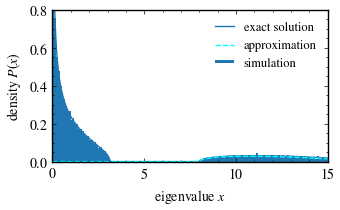

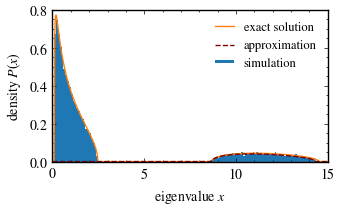

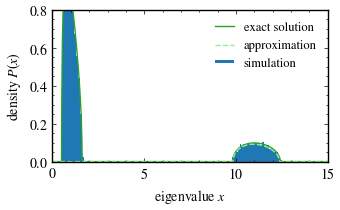

In [ ]:
# Parameters
my_A = [1, 2, 10]
sigma = 1
rank_ratio = 0.2
theta = np.sqrt(10.) # np.sqrt(10)
x_max = theta**2 + 5
EV_axis = np.linspace(0, x_max, 10**3 + 1)[1::]

# Exact
PDF_theo = [compute_theoretical_spectrum(EV_axis = EV_axis, sigma = sigma, A = A, rank_ratio = rank_ratio, theta = theta) for A in my_A]

# Approximation
large_PDF = [large_signal_PDF(EV_axis, sigma, A, rank_ratio, theta) for A in my_A]

# Experiment
histo_q_collection = [simulate_empirical_spectrum(
    sigma,
    A, 
    rank_ratio, 
    theta,
    dim_q = 500, 
    num_of_runs = 10,
    bin_interval = (0, x_max),
    num_bins = 150,
    seed = 0
) for A in my_A]

figs = plot_large_PDF_and_approximation(EV_axis, PDF_theo, large_PDF, histo_q_collection, my_A, x_max)

figs[1].savefig(f"./plots/Spectrum-Approx_Theta_signal{round(theta**2)}_r{round(rank_ratio*100)}_A{my_A[1]}.pdf")


In [23]:
def general_recursion_Green_single(z, A, sigma, rank_ratio, theta, func, tolerance=10**(-6), loop_control=10**6, starting_value=1+1j, imag_eps=1e-10):
    """
    For a single value z (eigenvalue axis), determines the Green function value iteratively.
    """
    # Setting up the loop parameters
    n_loop = 0
    old_G = starting_value
    rel_error = tolerance + 1
    
    # Compute fixed-point equation until precision or upper bound on loops is reached.
    while rel_error > tolerance and n_loop < loop_control:
        new_G = func(G = old_G, z = z + imag_eps * 1j, sigma = sigma, A = A, rank_ratio = rank_ratio, theta = theta)
        rel_error = np.abs(1 - old_G / new_G) 
        old_G = new_G
        n_loop += 1
    
    # Return value of eigenvalue density with corresponding number of loops or precision error.
    return np.array([new_G, rel_error, n_loop]) 


# Green function for multiple EVs 
def general_recursion_Green(EV_values, A, sigma, rank_ratio, theta, func, tolerance=10**(-6), loop_control=10**6, starting_value=1+1j, imag_eps=1e-10):
    """
    Determine the Green function values iteratively for every value in EV_values.
    
    EV_values: array (eigenvalue variable)
    k: scalar (lower power law bound)
    K: scalar (upper power law bound)
    A: scalar (dimension ratio)
    tolerance: scalar (precision of resulting value of spectral density)
    loop_control: scalar (upper bound on number of loops)
    starting_value: imag. scalar (first value of Green function 'm' to start loop with)
    imag_eps: scalar (small control parameter for convergence)
    
    output: array (Green function values)
    """
    # Depending on amount of 'z_values', determining the spectral density's values 'dist_values' is time consuming.
    time_start = time.time()
    dist_values = np.array([general_recursion_Green_single(_, A, sigma, rank_ratio, theta, func, tolerance=tolerance, starting_value=starting_value, imag_eps=imag_eps) for _ in EV_values])
    time_end = time.time()
    print(f"Runtime for Green function (A = {A}):", np.rint(time_end - time_start), "seconds")
    
    # Only return values themselves, not the error they come with. Can be easily changed by slicing.
    return dist_values[:, 0] 


def MP_fixed_point_general(G, z, sigma, A, rank_ratio, theta):
    """
    Computes the right-hand side of the self-consistency equation with a few degenerate signal eigenvalues (other than outliers there is a Marchenko-Pastur law).
    """
    # instead of integration: discrete signals with corresponding multiplicities counted as percentage of full rank (r/q)
    theta = np.array(theta)
    rank_ratio = np.array(rank_ratio)

    theta = np.concatenate((theta, np.zeros(1)))
    rank_ratio = np.concatenate((rank_ratio, np.ones(1) * (1 - np.sum(rank_ratio))))
   
    res = (z * (1 - sigma**2 / A * G) - sigma**2 * (1 - 1/A) - theta**2 / (1 - sigma**2 / A * G))**(-1)
    
    return np.sum(rank_ratio * res, axis = 0)



def compute_PDF_exact_multiple_signals(EV_axis, sigma, A, all_rank_ratios, all_thetas):
    """
    Computes the spectral density for given parameters by solving the Green function via recursion and then applying the Stieltjes inversion formula.
    """
    Green_rec = general_recursion_Green(EV_axis, A, sigma, all_rank_ratios, all_thetas, MP_fixed_point_general, imag_eps = 0)
    PDF_rec = PDF_from_Green(Green_rec, make_positive = True)

    return PDF_rec


def compute_PDF_approximation_multiple_signals(EV_axis, sigma, A, all_rank_ratios, all_thetas):
    """
    Computes the spectral density for given parameters by applying the large-signal approximation.
    """
    large_PDF = [large_signal_PDF(EV_axis, sigma, A, rank_ratio, theta) for rank_ratio, theta in zip(all_rank_ratios, all_thetas)]
    PDF_approx = np.sum(np.array(large_PDF), axis = 0)

    return PDF_approx


def plot_PDF_multiple_signals(EV_axis, PDF_rec, large_PDF, histo_q_collection, my_A, x_max, xlim=None, ylim=None):
    """
    Plots the spectral density for given parameters, including the histogram from the experiment, the exact solution and the approximation.
    """
    
    figs = [0]*len(my_A)
    for i, A in enumerate(my_A): 
        fig, ax = plt.subplots(figsize=(3.38582677, 2.093), constrained_layout=True)
        
        ax.bar(histo_q_collection[i][1][:-1:], histo_q_collection[i][0], color = my_colors_exp[0], align = "edge", width = np.diff(histo_q_collection[i][1]), label = r"simulation") # align = "center"
        ax.plot(EV_axis, PDF_rec[i], "-", color = my_colors_exp[i], label = r"exact solution")
        ax.plot(EV_axis, large_PDF[i], "--", color = "black", label = r"approximation")

        if xlim is not None:
            ax.set_xlim(xlim)
        if ylim is not None:
            ax.set_ylim(ylim)

        ax.set_xlabel(r"eigenvalue $x$", fontsize=10)
        ax.set_ylabel(r"density $P(x)$", fontsize=10)
        ax.tick_params(axis='both', labelsize=10)
        ax.legend(loc = "upper right", fontsize=9, handlelength=1.5, handleheight=0)

        figs[i] = fig

    plt.show()

    return figs

Theta values: [ 5.  9. 10. 14. 20.], Rank ratios: [0.002 0.002 0.002 0.002 0.002], Total rank ratio: 0.01
Runtime for Green function (A = 1): 32.0 seconds
Runtime for Green function (A = 2): 32.0 seconds
Runtime for Green function (A = 10): 78.0 seconds
Time for SV calculation (A = 1, q = 500): 2.8798 s
Time for SV calculation (A = 2, q = 500): 6.3015 s
Time for SV calculation (A = 10, q = 500): 20.5985 s


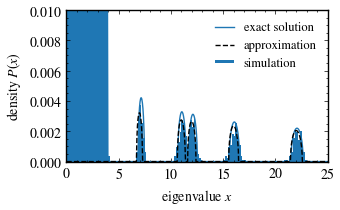

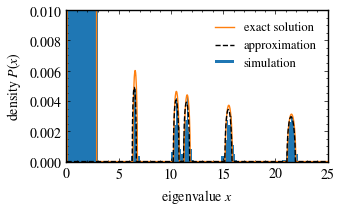

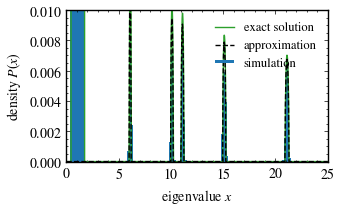

In [ ]:
# ETA = 10 min

# Parameters
sigma = 1
my_A = [1, 2, 10] 
all_thetas =  np.sqrt([5, 9, 10, 14, 20])
dim_q = 500
all_rank_ratios = np.ones(len(all_thetas)) / dim_q # each signal gets one rank ratio (here all the same)
x_max = max(all_thetas**2) + 5
EV_axis = np.linspace(0, x_max, 10**3 + 1)[1::]

print(f"Theta values: {all_thetas**2}, Rank ratios: {all_rank_ratios}, Total rank ratio: {np.sum(all_rank_ratios)}")

# Exact
PDF_rec = [compute_PDF_exact_multiple_signals(EV_axis, sigma, A, all_rank_ratios, all_thetas) for A in my_A]

# Approximation (for each signal theta)
large_PDF = [compute_PDF_approximation_multiple_signals(EV_axis, sigma, A, all_rank_ratios, all_thetas) for A in my_A]

# Experiment 
histo_q_collection = [simulate_empirical_spectrum(
    sigma,
    A, 
    all_rank_ratios, 
    all_thetas,
    dim_q = 500, 
    num_of_runs = 100,
    bin_interval = (0, x_max),
    num_bins = 150,
    seed = 0
) for A in my_A]


figs = plot_PDF_multiple_signals(EV_axis, PDF_rec, large_PDF, histo_q_collection, my_A, x_max, xlim = [0, x_max], ylim = [0, 0.5 * np.sum(all_rank_ratios)**(1/2) / 5])

figs[1].savefig(f"./plots/PDF-Multiple-Signals-Comparison_A{my_A[1]}_r{round(np.sum(all_rank_ratios)*100)}.pdf")

## Power-Law Signal Distribution

In [35]:
# Power Law Samples

def inv_cum_sum(y, k, K):
    """
    Calculates the functional inverse of the cumulative density function of a power law probability density with exponent -2.
    
    y: array (y-axis values in interval [0, 1])
    k: scalar (lower power law bound)
    K: scalar (upper power law bound) 
    
    output: array (x-axis values in interval [k, K], functional inverse of CDF)
    """
    return (1/k - y*(1/k - 1/K))**(-1)

def get_power2_samples(num, k, K):
    """
    Retrieves a finite set of samples from a power law probability density with exponent -2.
    
    num: scalar (number of points on x-axis)
    k: scalar (lower power law bound)
    K: scalar (upper power law bound) 
    
    output: array (x-axis values in interval [k, K], functional inverse of CDF)
    """
    return inv_cum_sum(np.linspace(0, 1, int(num)), k, K)


# Recursion function for a single EV z
def general_recursion_Green_single_v2(z, sigma, A, func, tolerance=10**(-6), loop_control=10**6, starting_value=1+1j, imag_eps=1e-10, **kwargs):
    """
    Iterative solution of some fixed-point equation for a single value z.
    """
    # Setting up the loop parameters
    n_loop = 0
    old_G = starting_value
    rel_error = tolerance + 1
    
    # Compute fixed-point equation until precision or upper bound on loops is reached.
    while rel_error > tolerance and n_loop < loop_control:
        new_G = func(G = old_G, z = z + imag_eps * 1j, sigma = sigma, A = A, **kwargs)
        rel_error = np.abs(1 - old_G / new_G) 
        old_G = new_G
        n_loop += 1
    
    # Return value of eigenvalue density with corresponding number of loops or precision error.
    return np.array([new_G, rel_error, n_loop]) 


def fixed_point_rhs_power_signal(G, z, sigma, A, k, K):
    """
    Right-hand side of the fixed-point equation for i.i.d. noise and power law distributed signals (exponent -2).
    """
    factor = (1 - sigma**2 / A * G)
    C = factor * ( z * factor - sigma**2 * (1 - 1/A) )
    rhs = factor / C**2 * (1/k - 1/K)**(-1) * np.log((1 - C / k) / (1 - C / K)) + factor / C
    
    return rhs
    


# Green function for multiple EVs 
def general_recursion_Green_v2(EV_values, sigma, A, func, tolerance=10**(-6), loop_control=10**6, starting_value=1+1j, imag_eps=1e-10, **kwargs):
    """
    Iterative solution of some fixed-point equation for all parameter values in EV_values.
    
    EV_values: array (eigenvalue variable)
    sigma: variance
    A: scalar (dimension ratio)
    func: function of right-hand side in fixed-point equation
    tolerance: scalar (precision of resulting value of spectral density)
    loop_control: scalar (upper bound on number of loops)
    starting_value: imag. scalar (first value of Green function 'm' to start loop with)
    imag_eps: scalar (small control parameter for convergence)
    
    output: array (Green function values)
    """
    # Depending on amount of 'z_values', determining the spectral density's values 'dist_values' is time consuming.
    time_start = time.time()
    dist_values = np.array([general_recursion_Green_single_v2(_, sigma, A, func, tolerance=tolerance, loop_control=loop_control, starting_value=starting_value, imag_eps=imag_eps, **kwargs) for _ in EV_values])
    time_end = time.time()
    print(f"Runtime for Green function (A = {A}):", np.rint(time_end - time_start), "seconds")
    
    # Only return values themselves, not the error they come with. Can be easily changed by slicing.
    return dist_values[:, 0] 


def compute_PDF_exact_power_signal(EV_axis, sigma, A, k, K):
    """
    Computes the spectral density for given parameters by solving the Green function via recursion and then applying the Stieltjes inversion formula.
    """
    Green_rec = general_recursion_Green_v2(EV_axis, sigma, A, fixed_point_rhs_power_signal, tolerance=1e-6, imag_eps=0, k = k, K = K)
    PDF_rec = PDF_from_Green(Green_rec, make_positive = True)

    return PDF_rec


def simulate_empirical_spectrum_v2(signal_SVs, sigma, A, dim_q, num_of_runs, num_bins, seed=0):

    variances = sigma**2 * np.ones(dim_q)

    start = time.time()
    exp_SV_q_collection = np.empty((num_of_runs, dim_q))
    for i in range(num_of_runs):
        exp_SV_q_collection[i] = np.linalg.svd(get_matrix(dim_q, A, variances, seed=seed+i) + signal_matrix(dim_q, A, signal_SVs), compute_uv=False)
    end = time.time()
    print(f"Time for SV calculation (A = {A}, q = {dim_q}): {end - start:.2f}", "s")
    
    exp_EV_q_collection = exp_SV_q_collection.flatten()**2 # squaring gives eigenvalues of sample covariance matrix

    histo_q = np.histogram(exp_EV_q_collection, bins = np.logspace(np.log10(np.min(exp_EV_q_collection)), np.log10(np.max(exp_EV_q_collection)), num_bins + 1), density=True)
    
    return histo_q


def plot_power_law_samples(signal_samples, k, K):
    signal_axis = np.logspace(np.log10(k), np.log10(K), 10)

    fig, ax = plt.subplots(figsize=(3.38582677, 2.093), constrained_layout=True)

    ax.hist(signal_samples, bins=np.logspace(np.log10(np.min(signal_samples)), np.log10(np.max(signal_samples)), 100), density=True, log=True, label="samples")
    ax.plot(signal_axis, signal_axis**(-2) / (1/k - 1/K), label="sampling distribution", color = "grey")
    ax.set_xlabel("eigenvalue $x$", fontsize=10)
    ax.set_ylabel("density $P(x)$", fontsize=10)
    ax.tick_params(axis='both', labelsize=10)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend()
    plt.show()


def plot_PDF_power_law(EV_axis, PDF_rec, histo_q_collection, my_A, k, K, xlim=None, ylim=None):

    fig, ax = plt.subplots(figsize=(3.38582677, 2.093), constrained_layout=True)

    ax.plot(np.logspace(np.log10(3), 2, 10), np.logspace(np.log10(3), 2, 10)**(-2) / (1/k - 1/K), "--", color = "grey")

    for i, A in enumerate(my_A):
        ax.plot(histo_q_collection[i][1][1::] - np.diff(histo_q_collection[i][1]) /2, histo_q_collection[i][0], ".", linewidth = 4, color = my_colors_exp[i])
        ax.plot(EV_axis, PDF_rec[i], "-", color = my_colors_exp[i], label = f"$\\mathcal{{A}} = {A}$")   

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    
    ax.set_xlabel(r"eigenvalue $x$", fontsize=10)
    ax.set_ylabel(r"density $P(x)$", fontsize=10)
    ax.tick_params(axis='both', labelsize=10)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(loc = (0.07, 0.05), fontsize=9, handlelength=1.5, handleheight=0)
    plt.show()

    return fig

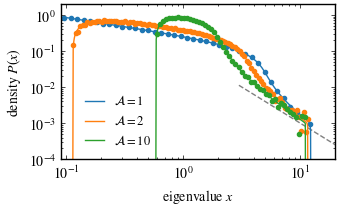

In [ ]:
# Parameters
sigma = 1
my_A = [1, 2, 10]
dim_q = 1000
k = 1e-1
K = 1e+1

# EV_axis = np.linspace(0, 40, 10**3 + 1)[1::]
EV_axis = np.logspace(-3, 2, 10**3 + 1)[1::]

# Exact
PDF_rec = [compute_PDF_exact_power_signal(EV_axis = EV_axis, sigma = sigma, A = A, k = k, K = K) for A in my_A]


# Simulations

# 1. Get power-law samples (signal values alias eigenvalues)
signal_EV_samples = get_power2_samples(dim_q, k, K)
plot_power_law_samples(signal_EV_samples, k, K)

# 2. Get matrix and determine SVs (for EV density)
bin_numbers = [200, 100, 50] # for A = 1, 2, 10, respectively
histo_q_collection = [simulate_empirical_spectrum_v2(
    signal_SVs = np.sqrt(signal_EV_samples),
    sigma = sigma,
    A = A,
    dim_q = dim_q,
    num_of_runs = 10,
    num_bins = bin_numbers[my_A.index(A)],
    seed = 0
) for A in my_A]


fig = plot_PDF_power_law(EV_axis, PDF_rec, histo_q_collection, my_A, k, K, xlim = [9e-2, 2e+1], ylim = [1e-4, 2e+0])

fig.savefig(f"./plots/Power-Law-Signals_Predictions-and-Simulations_q{dim_q}.pdf")